# Wine 데이터셋 Mean Shift 클러스터링

## 개요
- Wine 데이터셋에 Mean Shift 알고리즘 적용
- 밀도 기반 클러스터링 수행
- 클러스터 개수 자동 탐지

## 주요 단계
1. 데이터 로드 및 정규화
2. PCA 차원 축소 (13차원 → 2차원)
3. 대역폭 추정 및 클러스터링
4. 결과 시각화

## 라이브러리 임포트

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import MeanShift, estimate_bandwidth

## 1. 데이터 로드 및 전처리

- Wine 데이터셋: 178개 샘플, 13개 피처
- StandardScaler로 정규화 (거리 기반 알고리즘 특성상 필수)

In [2]:
# 와인 데이터셋 로드
wine = load_wine()
X = pd.DataFrame(wine.data, columns=wine.feature_names)

# 데이터 정규화
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"데이터 크기: {X.shape}")
print(f"\n데이터 샘플:\n{X.head()}")

데이터 크기: (178, 13)

데이터 샘플:
   alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
0    14.23        1.71  2.43               15.6      127.0           2.80   
1    13.20        1.78  2.14               11.2      100.0           2.65   
2    13.16        2.36  2.67               18.6      101.0           2.80   
3    14.37        1.95  2.50               16.8      113.0           3.85   
4    13.24        2.59  2.87               21.0      118.0           2.80   

   flavanoids  nonflavanoid_phenols  proanthocyanins  color_intensity   hue  \
0        3.06                  0.28             2.29             5.64  1.04   
1        2.76                  0.26             1.28             4.38  1.05   
2        3.24                  0.30             2.81             5.68  1.03   
3        3.49                  0.24             2.18             7.80  0.86   
4        2.69                  0.39             1.82             4.32  1.04   

   od280/od315_of_diluted_wines  pr

## 2. 차원 축소 (PCA)

- 13차원 → 2차원 축소
- 시각화 용이성 및 연산 효율 향상

In [3]:
# PCA 적용
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print(f"설명된 분산 비율: {pca.explained_variance_ratio_}")
print(f"총 설명된 분산: {sum(pca.explained_variance_ratio_):.2%}")

설명된 분산 비율: [0.36198848 0.1920749 ]
총 설명된 분산: 55.41%


## 3. 대역폭 추정 및 모델 학습

**대역폭(Bandwidth)**
- 밀도 계산 시 이웃 범위 결정
- quantile=0.2: 상위 20% 거리 기준
- 데이터 분포에 따라 자동 추정

In [4]:
# 대역폭 자동 추정
bandwidth = estimate_bandwidth(X_pca, quantile=0.2, n_samples=len(X_pca))
print(f"추정된 Bandwidth: {bandwidth:.4f}")

추정된 Bandwidth: 1.5256


**Mean Shift 학습**
- bin_seeding=True: 초기 중심점 그리드 설정 (연산 속도 향상)

In [5]:
# Mean Shift 모델 학습
ms = MeanShift(bandwidth=bandwidth, bin_seeding=True)
ms.fit(X_pca)

# 결과 추출
labels = ms.labels_
cluster_centers = ms.cluster_centers_
n_clusters_ = len(np.unique(labels))

print(f"발견된 군집 개수: {n_clusters_}")
print(f"\n군집 중심점:\n{cluster_centers}")

발견된 군집 개수: 3

군집 중심점:
[[ 2.27698717  0.93093939]
 [-0.5409327  -1.7993915 ]
 [-2.80786332  1.13531827]]


**군집별 샘플 개수**

In [6]:
# 각 군집별 샘플 개수
for k in range(n_clusters_):
    count = np.sum(labels == k)
    print(f"클러스터 {k}: {count}개")

클러스터 0: 67개
클러스터 1: 62개
클러스터 2: 49개


## 4. 결과 시각화

- 원형 마커: 군집별 데이터 포인트
- 붉은색 P: 밀도 중심점(피크)

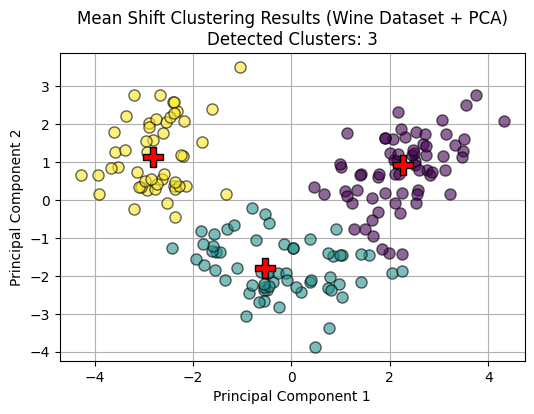

In [10]:
plt.figure(figsize=(6, 4))

# 군집별 색상 생성
colors = plt.cm.viridis(np.linspace(0, 1, n_clusters_))

for k, col in zip(range(n_clusters_), colors):
    my_members = (labels == k)
    cluster_center = cluster_centers[k]

    # 군집 데이터 포인트
    plt.plot(X_pca[my_members, 0], X_pca[my_members, 1], 'o',
             markerfacecolor=col, markeredgecolor='k', markersize=8, alpha=0.6)

    # 군집 중심점
    plt.plot(cluster_center[0], cluster_center[1], 'P',
             markerfacecolor='red', markeredgecolor='k', markersize=14)

plt.title(f'Mean Shift Clustering Results (Wine Dataset + PCA)\nDetected Clusters: {n_clusters_}')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True)
plt.show()

## 원본 레이블 비교 (선택사항)

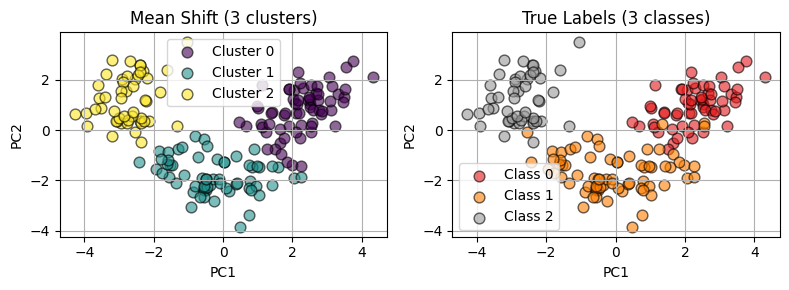

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(8, 3))

# Mean Shift 결과
colors_ms = plt.cm.viridis(np.linspace(0, 1, n_clusters_))
for k, col in zip(range(n_clusters_), colors_ms):
    my_members = (labels == k)
    axes[0].scatter(X_pca[my_members, 0], X_pca[my_members, 1],
                   c=[col], label=f'Cluster {k}', s=60, edgecolors='k', alpha=0.6)
axes[0].set_title(f'Mean Shift ({n_clusters_} clusters)')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
axes[0].legend()
axes[0].grid(True)

# 원본 레이블
colors_true = plt.cm.Set1(np.linspace(0, 1, len(np.unique(wine.target))))
for k, col in zip(np.unique(wine.target), colors_true):
    my_members = (wine.target == k)
    axes[1].scatter(X_pca[my_members, 0], X_pca[my_members, 1],
                   c=[col], label=f'Class {k}', s=60, edgecolors='k', alpha=0.6)
axes[1].set_title(f'True Labels ({len(np.unique(wine.target))} classes)')
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()